DEM Preprocessing
Reprojects and resamples raw 10m DEMs to 1km resolution for two regions:
- **Sierra Nevada / Lake Tahoe** → UTM Zone 11N (EPSG:26911) → `CA_DEM_AOI_1km.tif`
- **Colorado Mountains**         → UTM Zone 13N (EPSG:32613) → `CO_DEM_AOI_1km.tif`

Input:  `Data/Elevation/<region>_DEM_AOI_TNM_10m.tif`  (from get_elevation.R)
Output: `Data/Elevation/CA_DEM_AOI_1km.tif`
`Data/Elevation/CO_DEM_AOI_1km.tif`

Workflow per region:
1. Reproject 10m DEM to UTM
2. Resample to 1km (average pooling)
3. Clip to AOI polygon — cells outside polygon written as NaN (nodata)
4. Verify NaNs exist only outside polygon, not inside

No intermediate TIFs are written to disk.

In [16]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterio.mask import mask
from rasterio.io import MemoryFile
from shapely.geometry import Polygon, mapping
from pyproj import Transformer
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from rasterio.plot import show

# --------------------------------------------------------------------
# Paths
# Scripts/data_collection/
# --------------------------------------------------------------------
REPO_ROOT = Path().resolve().parents[0]
ELEV_DIR  = REPO_ROOT / "Data" / "Elevation"

print("Repo root :", REPO_ROOT)
print("Elev dir  :", ELEV_DIR)

# --------------------------------------------------------------------
# Region config
# --------------------------------------------------------------------
REGIONS = {
    "california": {
        "input_tif":  ELEV_DIR / "california_DEM_AOI_TNM_10m.tif",
        "output_tif": ELEV_DIR / "CA_DEM_AOI_1km.tif",
        "utm_crs":    "EPSG:26911",
        "label":      "Sierra Nevada / Lake Tahoe",
        # (lon, lat) WGS84 — matches get_elevation.R
        "aoi_lonlat": [
            (-119.45505750721992, 39.65343608043361),
            (-121.27878797084242, 39.66189413918429),
            (-119.11448133630248, 36.726935737063016),
            (-118.49924696303225, 37.235952484988736),
            (-119.46604383531404, 38.37304030164334),
        ],
    },
    "colorado": {
        "input_tif":  ELEV_DIR / "colorado_DEM_AOI_TNM_10m.tif",
        "output_tif": ELEV_DIR / "CO_DEM_AOI_1km.tif",
        "utm_crs":    "EPSG:32613",
        "label":      "Colorado Mountains",
        # (lon, lat) WGS84 — matches get_elevation.R
        "aoi_lonlat": [
            (-105.19885928678391, 40.62046076499234),
            (-106.88927700287375, 40.555465783967925),
            (-107.66078646416787, 38.79540171139857),
            (-104.87856373593310, 38.77382201116306),
        ],
    },
}

TARGET_RES = 1000  # metres


# --------------------------------------------------------------------
# Helper: project AOI polygon from WGS84 → target UTM CRS
# --------------------------------------------------------------------

def project_polygon(lonlat_vertices: list, dst_crs: str) -> Polygon:
    transformer = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    projected = [transformer.transform(lon, lat) for lon, lat in lonlat_vertices]
    return Polygon(projected)


# --------------------------------------------------------------------
# Main processing function
# --------------------------------------------------------------------

def process_dem(region_name: str, cfg: dict, target_res: int = 1000):
    print(f"\n{'='*60}")
    print(f"  Processing: {cfg['label']}")
    print(f"{'='*60}")

    input_tif  = cfg["input_tif"]
    output_tif = cfg["output_tif"]
    dst_crs    = cfg["utm_crs"]

    if not input_tif.exists():
        raise FileNotFoundError(
            f"Input DEM not found: {input_tif}\n"
            "Run get_elevation.R first."
        )

    # ----------------------------------------------------------------
    # Step 1: Inspect original
    # ----------------------------------------------------------------
    with rasterio.open(input_tif) as src:
        print(f"Original CRS        : {src.crs}")
        print(f"Original resolution : {src.res}")
        print(f"Original shape      : {src.height} x {src.width}")

    # ----------------------------------------------------------------
    # Step 2: Reproject to UTM (bilinear, stays at native ~10m res)
    # ----------------------------------------------------------------
    print(f"\nReprojecting to {dst_crs}...")

    with rasterio.open(input_tif) as src:
        utm_transform, utm_width, utm_height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        utm_profile = src.profile.copy()
        utm_profile.update({
            "crs":       dst_crs,
            "transform": utm_transform,
            "width":     utm_width,
            "height":    utm_height,
            "dtype":     "float32",
            "nodata":    None,
        })

        dem_utm = np.empty((utm_height, utm_width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dem_utm,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=utm_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )

    print(f"  UTM shape: {utm_height} x {utm_width}")

    # ----------------------------------------------------------------
    # Step 3: Resample to 1km (average pooling)
    # ----------------------------------------------------------------
    print(f"\nResampling to {target_res}m...")

    orig_res_x = abs(utm_transform.a)
    orig_res_y = abs(utm_transform.e)

    new_width  = max(1, int(round(utm_width  * orig_res_x / target_res)))
    new_height = max(1, int(round(utm_height * orig_res_y / target_res)))

    km_transform = rasterio.Affine(
        target_res,  0, utm_transform.c,
        0, -target_res, utm_transform.f,
    )

    dem_1km = np.empty((new_height, new_width), dtype=np.float32)
    reproject(
        source=dem_utm,
        destination=dem_1km,
        src_transform=utm_transform,
        src_crs=dst_crs,
        dst_transform=km_transform,
        dst_crs=dst_crs,
        resampling=Resampling.average,
    )
    del dem_utm  # free large intermediate array

    km_profile = {
        "driver":    "GTiff",
        "height":    new_height,
        "width":     new_width,
        "count":     1,
        "dtype":     "float32",
        "crs":       dst_crs,
        "transform": km_transform,
        "nodata":    np.nan,
        "compress":  "lzw",
    }

    print(f"  1km shape : {new_height} x {new_width}")

    # ----------------------------------------------------------------
    # Step 4: Clip to AOI polygon via in-memory file
    # Cells outside the polygon are set to NaN (nodata)
    # ----------------------------------------------------------------
    print("\nClipping to AOI polygon...")

    aoi_utm = project_polygon(cfg["aoi_lonlat"], dst_crs)

    with MemoryFile() as memfile:
        with memfile.open(**km_profile) as mem_ds:
            mem_ds.write(dem_1km, 1)

        with memfile.open() as mem_ds:
            out_image, out_transform = mask(
                mem_ds,
                [mapping(aoi_utm)],
                crop=True,
                filled=True,
                nodata=np.nan,
            )
            out_profile = mem_ds.profile.copy()
            out_profile.update({
                "height":    out_image.shape[1],
                "width":     out_image.shape[2],
                "transform": out_transform,
                "nodata":    np.nan,
                "dtype":     "float32",
            })

    clipped = out_image[0]

    # ----------------------------------------------------------------
    # Step 5: Verify — NaNs should exist only outside the polygon
    # ----------------------------------------------------------------
    nan_mask   = np.isnan(clipped)
    nan_count  = nan_mask.sum()
    valid_count = (~nan_mask).sum()
    total_count = clipped.size

    print(f"\n  Valid cells : {valid_count:,} / {total_count:,}")
    print(f"  NaN cells   : {nan_count:,} (outside polygon — expected)")

    if valid_count == 0:
        raise ValueError(
            f"[{cfg['label']}] No valid cells after clipping — "
            "check that AOI polygon overlaps the DEM extent."
        )

    # ----------------------------------------------------------------
    # Step 6: Write final TIF
    # ----------------------------------------------------------------
    output_tif.parent.mkdir(parents=True, exist_ok=True)
    if output_tif.exists():
        output_tif.unlink()

    with rasterio.open(output_tif, "w", **out_profile) as dst:
        dst.write(clipped, 1)

    print(f"\n  Saved: {output_tif}")

    # ----------------------------------------------------------------
    # Step 7: Inline diagnostics (valid cells only)
    # ----------------------------------------------------------------
    valid = clipped[~nan_mask]
    print(f"\n--- Diagnostics: {cfg['label']} ---")
    print(f"  Shape      : {clipped.shape}  (rows x cols)")
    print(f"  CRS        : {dst_crs}")
    print(f"  Resolution : {target_res}m x {target_res}m")
    print(f"  Min / Max  : {valid.min():.1f}m / {valid.max():.1f}m")
    print(f"  Mean / Std : {valid.mean():.1f}m / {valid.std():.1f}m")

    return output_tif

Repo root : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
Elev dir  : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\Elevation


In [18]:
# --------------------------------------------------------------------
# Run both regions
# --------------------------------------------------------------------
for region_name, cfg in REGIONS.items():
    process_dem(region_name, cfg, TARGET_RES)


  Processing: Sierra Nevada / Lake Tahoe
Original CRS        : EPSG:4269
Original resolution : (9.259259266022021e-05, 9.259259265990935e-05)
Original shape      : 31697 x 30019

Reprojecting to EPSG:26911...
  UTM shape: 35771 x 27209

Resampling to 1000m...
  1km shape : 333 x 254

Clipping to AOI polygon...

  Valid cells : 28,848 / 78,255
  NaN cells   : 49,407 (outside polygon — expected)

  Saved: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\Elevation\CA_DEM_AOI_1km.tif

--- Diagnostics: Sierra Nevada / Lake Tahoe ---
  Shape      : (333, 235)  (rows x cols)
  CRS        : EPSG:26911
  Resolution : 1000m x 1000m
  Min / Max  : 345.6m / 3921.4m
  Mean / Std : 2072.8m / 625.9m

  Processing: Colorado Mountains
Original CRS        : EPSG:4269
Original resolution : (9.259259266022024e-05, 9.259259265990947e-05)
Original shape      : 19944 x 30048

Reprojecting to EPSG:32613...
  UTM shape: 23891 x 27715

Resampling to 1000m...
  1km shape : 2

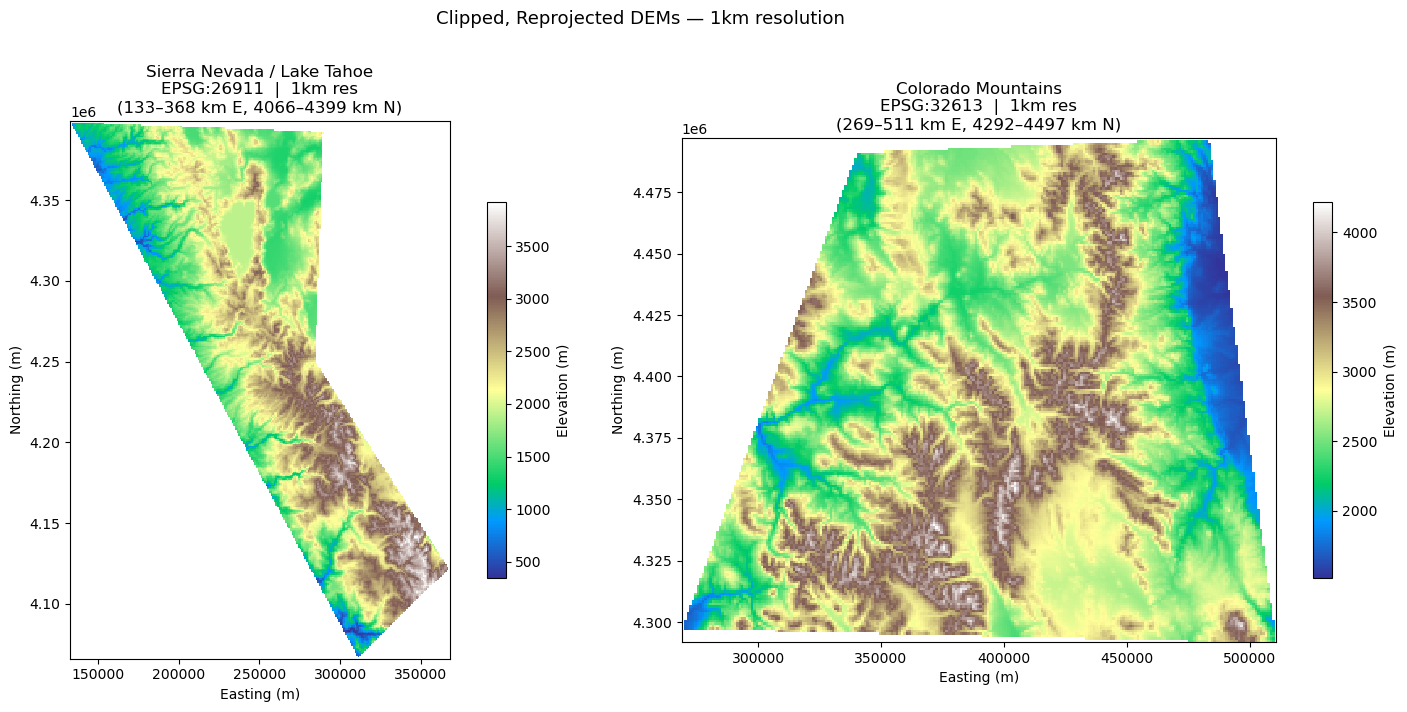

In [19]:
# --------------------------------------------------------------------
# Visualize both DEMs — masked to polygon shape, NaNs transparent
# --------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (region_name, cfg) in zip(axes, REGIONS.items()):
    out_path = cfg["output_tif"]
    if not out_path.exists():
        ax.set_title(f"{cfg['label']}\n(not yet processed)")
        ax.axis("off")
        continue

    with rasterio.open(out_path) as src:
        arr      = src.read(1).astype(float)
        extent   = [src.bounds.left, src.bounds.right,
                    src.bounds.bottom, src.bounds.top]
        b        = src.bounds

    # Mask NaNs so only polygon interior is rendered
    arr_masked = np.ma.masked_invalid(arr)

    im = ax.imshow(
        arr_masked,
        cmap="terrain",
        extent=extent,
        origin="upper",
        interpolation="none",
    )
    plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)
    ax.set_title(
        f"{cfg['label']}\n"
        f"{cfg['utm_crs']}  |  1km res\n"
        f"({b.left/1e3:.0f}–{b.right/1e3:.0f} km E, "
        f"{b.bottom/1e3:.0f}–{b.top/1e3:.0f} km N)"
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.suptitle("Clipped, Reprojected DEMs — 1km resolution", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# --------------------------------------------------------------------
# Detailed diagnostics for each output file
# --------------------------------------------------------------------
for region_name, cfg in REGIONS.items():
    out_path = cfg["output_tif"]
    if not out_path.exists():
        print(f"\n{cfg['label']}: output not found, skipping.")
        continue

    with rasterio.open(out_path) as src:
        arr       = src.read(1).astype(float)
        transform = src.transform
        crs       = src.crs
        bounds    = src.bounds
        res       = (abs(transform.a), abs(transform.e))

    valid = arr[~np.isnan(arr)]

    print(f"\n{'='*52}")
    print(f"  {cfg['label']}")
    print(f"{'='*52}")
    print(f"  File         : {out_path.name}")
    print(f"  CRS          : {crs}")
    print(f"  Resolution   : {res[0]:.0f} x {res[1]:.0f} m")
    print(f"  Shape        : {arr.shape}  (rows x cols)")
    print(f"  Bounds       : {bounds}")
    print(f"\n  --- Valid cells only ---")
    print(f"  Valid / Total: {len(valid):,} / {arr.size:,}")
    print(f"  Min          : {valid.min():.2f} m")
    print(f"  Max          : {valid.max():.2f} m")
    print(f"  Mean         : {valid.mean():.2f} m")
    print(f"  Std          : {valid.std():.2f} m")
    print(f"\n  --- Data Integrity ---")
    print(f"  NaNs (outside polygon) : {np.isnan(arr).sum():,}")
    print(f"  +Inf                   : {np.isposinf(arr).sum():,}")
    print(f"  -Inf                   : {np.isneginf(arr).sum():,}")


  Sierra Nevada / Lake Tahoe
  File         : CA_DEM_AOI_1km.tif
  CRS          : EPSG:26911
  Resolution   : 1000 x 1000 m
  Shape        : (333, 235)  (rows x cols)
  Bounds       : BoundingBox(left=132830.58548976987, bottom=4065984.824855651, right=367830.5854897699, top=4398984.824855651)

  --- Valid cells only ---
  Valid / Total: 28,848 / 78,255
  Min          : 345.56 m
  Max          : 3921.40 m
  Mean         : 2072.78 m
  Std          : 625.93 m

  --- Data Integrity ---
  NaNs (outside polygon) : 49,407
  +Inf                   : 0
  -Inf                   : 0

  Colorado Mountains
  File         : CO_DEM_AOI_1km.tif
  CRS          : EPSG:32613
  Resolution   : 1000 x 1000 m
  Shape        : (205, 242)  (rows x cols)
  Bounds       : BoundingBox(left=268851.5946253396, bottom=4292029.881588113, right=510851.5946253396, top=4497029.881588113)

  --- Valid cells only ---
  Valid / Total: 38,342 / 49,610
  Min          : 1516.20 m
  Max          : 4220.51 m
  Mean         : 